# WiFiスニッフィング (Beacon版) 消費電流解析

esp32_command_beacon.ino を使用した電流データを解析する。

**測定パターン**: 1秒, 3秒, 5秒, 10秒 × 各10回

**サイクル**: ESP32電源ON → ブート → スキャン → ESP32電源OFF → 5秒インターバル

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 設定
# ============================================================
CSV_FILE = 'dist/current_log_wifi_beacon.csv'

ON_THRESHOLD_MA = 30.0

SCAN_PATTERNS_MS = [1000, 3000, 5000, 10000]
REPS_PER_PATTERN = 10

In [2]:
# ============================================================
# データ読み込み
# ============================================================
df = pd.read_csv(CSV_FILE)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.reset_index(drop=True)
df['elapsed_s'] = (df['Timestamp'] - df['Timestamp'].iloc[0]).dt.total_seconds()

print(f'データ件数: {len(df)}')
print(f'時間範囲: {df["Timestamp"].iloc[0]} ~ {df["Timestamp"].iloc[-1]}')
print(f'サンプリング間隔: {df["elapsed_s"].diff().median()*1000:.1f} ms')

データ件数: 10626
時間範囲: 2026-03-18 19:16:13.492373 ~ 2026-03-18 19:25:21.459286
サンプリング間隔: 50.8 ms


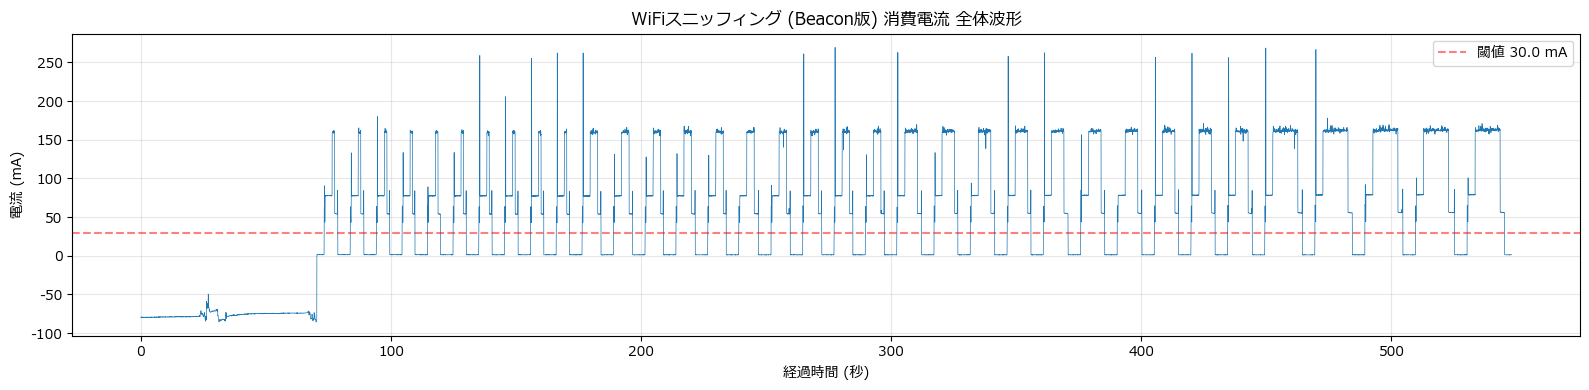

In [3]:
# ============================================================
# 全体の電流波形
# ============================================================
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df['elapsed_s'], df['Current (mA)'], linewidth=0.5)
ax.set_xlabel('経過時間 (秒)')
ax.set_ylabel('電流 (mA)')
ax.set_title('WiFiスニッフィング (Beacon版) 消費電流 全体波形')
ax.axhline(y=ON_THRESHOLD_MA, color='r', linestyle='--', alpha=0.5, label=f'閾値 {ON_THRESHOLD_MA} mA')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# ESP32 ON区間の自動検出
# ============================================================
current = df['Current (mA)'].values
timestamps = df['elapsed_s'].values

is_on = current > ON_THRESHOLD_MA
transitions = np.diff(is_on.astype(int))
on_starts = np.where(transitions == 1)[0] + 1
on_ends = np.where(transitions == -1)[0] + 1

if is_on[0]:
    on_starts = np.insert(on_starts, 0, 0)
if is_on[-1]:
    on_ends = np.append(on_ends, len(is_on))

n_cycles = min(len(on_starts), len(on_ends))
on_starts = on_starts[:n_cycles]
on_ends = on_ends[:n_cycles]

valid = []
for s, e in zip(on_starts, on_ends):
    duration = timestamps[min(e, len(timestamps)-1)] - timestamps[s]
    if duration >= 1.0:
        valid.append((s, e))

print(f'検出されたON区間: {len(valid)} 回')
print(f'期待値: {len(SCAN_PATTERNS_MS) * REPS_PER_PATTERN} 回')

検出されたON区間: 35 回
期待値: 40 回


In [5]:
# ============================================================
# 各ON区間の統計 (ベースライン差し引き)
# ============================================================
results = []
total_expected = len(SCAN_PATTERNS_MS) * REPS_PER_PATTERN

# 先にベースライン算出
all_on_indices = set()
for s, e in valid:
    all_on_indices.update(range(s, e))
off_mask = ~df.index.isin(all_on_indices)
baseline = df.loc[off_mask, 'Current (mA)'].mean()
print(f'ベースライン電流 (ESP32 OFF): {baseline:.2f} mA\n')

for i, (s, e) in enumerate(valid):
    segment = df.iloc[s:e]
    duration_s = segment['elapsed_s'].iloc[-1] - segment['elapsed_s'].iloc[0]
    mean_ma = segment['Current (mA)'].mean() - baseline  # ベースライン差し引き
    peak_ma = segment['Current (mA)'].max() - baseline

    if i < total_expected:
        pattern_idx = i // REPS_PER_PATTERN
        rep_idx = i % REPS_PER_PATTERN
        scan_ms = SCAN_PATTERNS_MS[pattern_idx] if pattern_idx < len(SCAN_PATTERNS_MS) else -1
    else:
        scan_ms = -1
        rep_idx = i

    results.append({
        'cycle': i + 1,
        'scan_ms': scan_ms,
        'rep': rep_idx + 1,
        'duration_s': duration_s,
        'mean_mA': mean_ma,
        'peak_mA': peak_ma,
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

ベースライン電流 (ESP32 OFF): -19.97 mA

 cycle  scan_ms  rep  duration_s    mean_mA    peak_mA
     1     1000    1    5.381457 108.552991 182.166393
     2     1000    2    5.331683 107.239978 185.266393
     3     1000    3    5.204885 108.301345 199.966393
     4     1000    4    5.052690 107.939393 182.166393
     5     1000    5    5.154266 106.936690 182.266393
     6     1000    6    5.179572 107.948918 183.066393
     7     1000    7    5.256195 107.935624 278.866393
     8     1000    8    5.306405 107.874965 225.566393
     9     1000    9    5.179236 108.923675 275.266393
    10     1000   10    5.230585 108.513509 282.166393
    11     3000    1    7.465324 126.458285 282.066393
    12     3000    2    7.514874 125.756326 185.966393
    13     3000    3    7.261753 127.608754 185.066393
    14     3000    4    7.616674 124.919373 187.566393
    15     3000    5    7.312047 127.162945 185.766393
    16     3000    6    7.819879 123.861165 185.766393
    17     3000    7    7.616299

In [6]:
# ============================================================
# パターンごとの集計 (ベースライン差し引き済み)
# ============================================================
summary = df_results[df_results['scan_ms'] > 0].groupby('scan_ms').agg(
    回数=('mean_mA', 'count'),
    ON区間_平均秒=('duration_s', 'mean'),
    平均電流_mA=('mean_mA', 'mean'),
    電流標準偏差_mA=('mean_mA', 'std'),
    ピーク電流_mA=('peak_mA', 'max'),
).reset_index()
summary.columns = ['スキャン時間(ms)', '回数', 'ON区間平均(秒)', '平均電流(mA)', '標準偏差(mA)', 'ピーク電流(mA)']

print('=== パターンごとの集計 (ベースライン差し引き済み) ===')
print(summary.to_string(index=False))
print(f'\n※ ベースライン {baseline:.2f} mA を差し引いた値')

=== パターンごとの集計 (ベースライン差し引き済み) ===
 スキャン時間(ms)  回数  ON区間平均(秒)   平均電流(mA)  標準偏差(mA)  ピーク電流(mA)
       1000  10   5.227697 108.016709  0.600463 282.166393
       3000  10   7.493020 126.191139  1.388515 289.366393
       5000  10   9.627892 137.205512  1.206909 282.866393
      10000   5  15.086691 150.803460  1.482499 288.466393

※ ベースライン -19.97 mA を差し引いた値


In [7]:
# ============================================================
# Probe Request版との比較
# ============================================================
probe_results = {
    1000: {'mean': 152.6, 'peak': 345.4, 'duration': 4.3},
    3000: {'mean': 159.1, 'peak': 353.0, 'duration': 6.4},
    5000: {'mean': 162.1, 'peak': 363.7, 'duration': 8.5},
    10000: {'mean': 165.8, 'peak': 363.0, 'duration': 13.6},
}

print('=== Probe Request版 vs Beacon版 比較 ===')
print(f'{"スキャン(ms)":>12} {"Probe平均(mA)":>14} {"Beacon平均(mA)":>14} {"差(mA)":>8}')
for _, row in summary.iterrows():
    ms = int(row['スキャン時間(ms)'])
    beacon_mean = row['平均電流(mA)']
    if ms in probe_results:
        probe_mean = probe_results[ms]['mean']
        diff = beacon_mean - probe_mean
        print(f'{ms:>12} {probe_mean:>14.1f} {beacon_mean:>14.1f} {diff:>8.1f}')
    else:
        print(f'{ms:>12} {"N/A":>14} {beacon_mean:>14.1f} {"N/A":>8}')

=== Probe Request版 vs Beacon版 比較 ===
    スキャン(ms)    Probe平均(mA)   Beacon平均(mA)    差(mA)
        1000          152.6          108.0    -44.6
        3000          159.1          126.2    -32.9
        5000          162.1          137.2    -24.9
       10000          165.8          150.8    -15.0


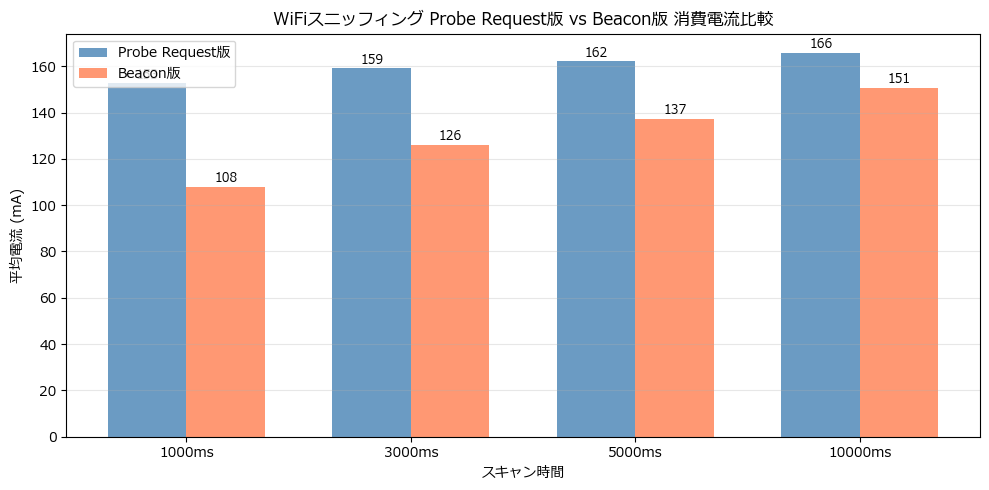

In [8]:
# ============================================================
# パターンごとの平均電流グラフ (Probe vs Beacon)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(SCAN_PATTERNS_MS))
width = 0.35

probe_means = [probe_results[ms]['mean'] for ms in SCAN_PATTERNS_MS]
beacon_means = []
for ms in SCAN_PATTERNS_MS:
    row = summary[summary['スキャン時間(ms)'] == ms]
    beacon_means.append(row['平均電流(mA)'].values[0] if len(row) > 0 else 0)

ax.bar(x - width/2, probe_means, width, label='Probe Request版', color='steelblue', alpha=0.8)
ax.bar(x + width/2, beacon_means, width, label='Beacon版', color='coral', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f'{ms}ms' for ms in SCAN_PATTERNS_MS])
ax.set_xlabel('スキャン時間')
ax.set_ylabel('平均電流 (mA)')
ax.set_title('WiFiスニッフィング Probe Request版 vs Beacon版 消費電流比較')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for i, (p, b) in enumerate(zip(probe_means, beacon_means)):
    ax.text(i - width/2, p + 2, f'{p:.0f}', ha='center', fontsize=9)
    ax.text(i + width/2, b + 2, f'{b:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()